<a href="https://colab.research.google.com/github/tanutiwarii/NLP-NOTES/blob/main/6_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sentiment Classification Using BERT**
BERT is a language model developed by Google in 2018 that revolutionized how machines understand human language. Its key innovation is bidirectional training – reading text in both directions (left-to-right and right-to-left) simultaneously.

### **BERT Architecture**

Two main versions:

- **BERT-base:** 12 layers, 110 million parameters
- **BERT-large:** 24 layers, 340 million parameters

In [1]:
!pip install transformers==4.41.2

In [2]:
import os
import shutil
import tarfile
import tensorflow as tf
from transformers import BertTokenizer, TFBertForSequenceClassification
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.offline as pyo
import plotly.graph_objects as go
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

### **Step 2: Load the dataset**

In [3]:
current_folder = os.getcwd()

dataset = tf.keras.utils.get_file(
    fname ="aclImdb.tar.gz",
    origin ="http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
    cache_dir=  current_folder,
    extract = True)

84125825/84125825 [==============================] - 1s 0us/step


**Check the dataset folder**

In [4]:
dataset_path = os.path.dirname(dataset)
os.listdir(dataset_path)

['aclImdb', 'aclImdb.tar.gz']

**Check the 'aclImdb' directory**

In [5]:
dataset_dir = os.path.join(dataset_path, 'aclImdb')

os.listdir(dataset_dir)

['imdb.vocab', 'README', 'train', 'test', 'imdbEr.txt']

**Check the 'Train' dataset folder**

In [6]:
train_dir = os.path.join(dataset_dir,'train')
os.listdir(train_dir)

['unsup',
 'unsupBow.feat',
 'urls_pos.txt',
 'urls_neg.txt',
 'urls_unsup.txt',
 'labeledBow.feat',
 'pos',
 'neg']

**Read the files of the 'Train' directory files**

In [7]:
for file in os.listdir(train_dir):
    file_path = os.path.join(train_dir, file)
    if os.path.isfile(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            first_value = f.readline().strip()
            print(f"{file}: {first_value}")
    else:
        print(f"{file}: {file_path}")

unsup: /content/datasets/aclImdb/train/unsup
unsupBow.feat: 0 0:8 1:6 3:5 4:2 5:1 7:1 8:5 9:2 10:1 11:2 13:3 16:1 17:1 18:1 19:1 22:3 24:1 26:3 28:1 30:1 31:1 35:2 36:1 39:2 40:1 41:2 46:2 47:1 48:1 52:1 63:1 67:1 68:1 74:1 81:1 83:1 87:1 104:1 105:1 112:1 117:1 131:1 151:1 155:1 170:1 198:1 225:1 226:1 288:2 291:1 320:1 331:1 342:1 364:1 374:1 384:2 385:1 407:1 437:1 441:1 465:1 468:1 470:1 519:1 595:1 615:1 650:1 692:1 851:1 937:1 940:1 1100:1 1264:1 1297:1 1317:1 1514:1 1728:1 1793:1 1948:1 2088:1 2257:1 2358:1 2584:2 2645:1 2735:1 3050:1 4297:1 5385:1 5858:1 7382:1 7767:1 7773:1 9306:1 10413:1 11881:1 15907:1 18613:1 18877:1 25479:1
urls_pos.txt: http://www.imdb.com/title/tt0453418/usercomments
urls_neg.txt: http://www.imdb.com/title/tt0064354/usercomments
urls_unsup.txt: http://www.imdb.com/title/tt0018515/usercomments
labeledBow.feat: 9 0:9 1:1 2:4 3:4 4:6 5:4 6:2 7:2 8:4 10:4 12:2 26:1 27:1 28:1 29:2 32:1 41:1 45:1 47:1 50:1 54:2 57:1 59:1 63:2 64:1 66:1 68:2 70:1 72:1 78:1 100:

**Load the Movies reviews and convert them into the pandas' data frame with their respective sentiment**

Here 0 means Negative and 1 means Positive

In [8]:
def load_dataset(directory):
    data = {"sentence": [], "sentiment": []}
    for file_name in os.listdir(directory):
        print(file_name)
        if file_name == 'pos':
            positive_dir = os.path.join(directory, file_name)
            for text_file in os.listdir(positive_dir):
                text = os.path.join(positive_dir, text_file)
                with open(text, "r", encoding="utf-8") as f:
                    data["sentence"].append(f.read())
                    data["sentiment"].append(1)
        elif file_name == 'neg':
            negative_dir = os.path.join(directory, file_name)
            for text_file in os.listdir(negative_dir):
                text = os.path.join(negative_dir, text_file)
                with open(text, "r", encoding="utf-8") as f:
                    data["sentence"].append(f.read())
                    data["sentiment"].append(0)

    return pd.DataFrame.from_dict(data)

**Load the training datasets**

In [9]:
train_df = load_dataset(train_dir)
print(train_df.head())

unsup
unsupBow.feat
urls_pos.txt
urls_neg.txt
urls_unsup.txt
labeledBow.feat
pos
neg
                                            sentence  sentiment
0  I may be biased, I am the author of the novel ...          1
1  This musical was not quite what I expected, fo...          1
2  When I started watching "Fay Grim", I had no i...          1
3  Samuel Fuller brings his customary playful and...          1
4  Back to the roots with "like it is in heaven" ...          1


**Load the test dataset respectively**

In [10]:
test_dir = os.path.join(dataset_dir,'test')
test_df = load_dataset(test_dir)
print(test_df.head())

urls_pos.txt
urls_neg.txt
labeledBow.feat
pos
neg
                                            sentence  sentiment
0  this movie had me stuck in this endless loop o...          1
1  Christopher Nolan's first feature film wowed c...          1
2  I enjoyed this series, but felt that the whole...          1
3  This film easily rivals the emotional strength...          1
4  I will admit, I had the opportunity in the pas...          1


### **Step 3: Preprocessing**

In [11]:
sentiment_counts = train_df['sentiment'].value_counts()

fig =px.bar(x= {0:'Negative',1:'Positive'},
            y= sentiment_counts.values,
            color=sentiment_counts.index,
            color_discrete_sequence =  px.colors.qualitative.Dark24,
            title='<b>Sentiments Counts')

fig.update_layout(title='Sentiments Counts',
                  xaxis_title='Sentiment',
                  yaxis_title='Counts',
                  template='plotly_dark')


fig.show()
pyo.plot(fig, filename = 'Sentiments Counts.html', auto_open = True)

'Sentiments Counts.html'

**Text Cleaning**

In [12]:
def text_cleaning(text):
    soup = BeautifulSoup(text, "html.parser")
    text = re.sub(r'\[[^]]*\]', '', soup.get_text())
    pattern = r"[^a-zA-Z0-9\s,']"
    text = re.sub(pattern, '', text)
    return text

**Apply text_cleaning**

In [13]:
train_df['Cleaned_sentence'] = train_df['sentence'].apply(text_cleaning).tolist()
test_df['Cleaned_sentence'] = test_df['sentence'].apply(text_cleaning)

**Plot reviews on WordCLouds**

In [14]:
def generate_wordcloud(text,Title):
    all_text = " ".join(text)
    wordcloud = WordCloud(width=800,
                          height=400,
                          stopwords=set(STOPWORDS),
                          background_color='black').generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(Title)
    plt.show()

**Positive Reviews**

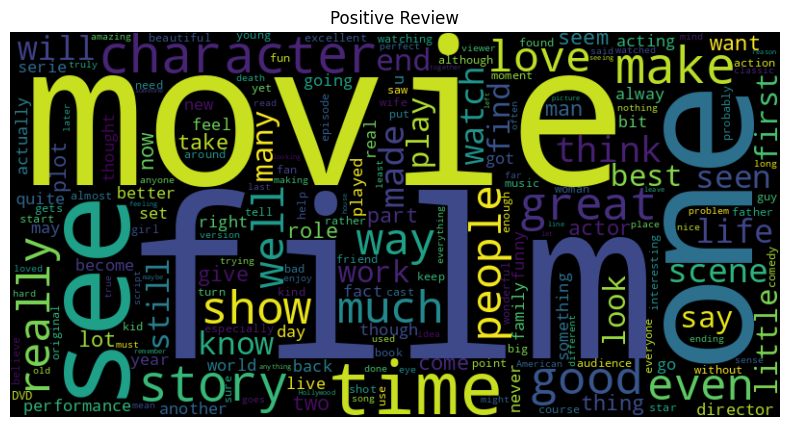

In [15]:
positive = train_df[train_df['sentiment']==1]['Cleaned_sentence'].tolist()
generate_wordcloud(positive,'Positive Review')

**Negative Reviews**

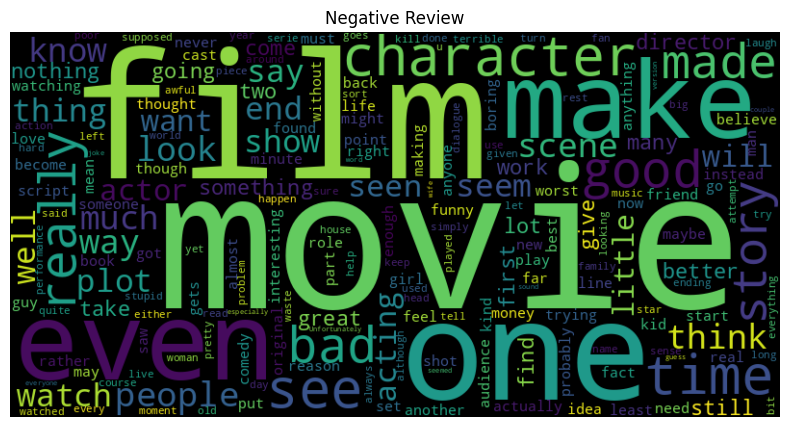

In [16]:
negative = train_df[train_df['sentiment']==0]['Cleaned_sentence'].tolist()
generate_wordcloud(negative,'Negative Review')

**Separate input text and target sentiment of both train and test**

In [17]:
Reviews = train_df['Cleaned_sentence']
Target = train_df['sentiment']

test_reviews = test_df['Cleaned_sentence']
test_targets = test_df['sentiment']

**Split TEST data into test and validation**

In [18]:
x_val, x_test, y_val, y_test = train_test_split(test_reviews,
                                                    test_targets,
                                                    test_size=0.5,
                                                    stratify = test_targets)

### **Step 4: Tokenization & Encoding**

BERT tokenization is used to convert the raw text into numerical inputs that can be fed into the BERT model. It tokenized the text and performs some preprocessing to prepare the text for the model's input format. Let's understand some of the key features of the BERT tokenization model.

BERT tokenizer splits the words into subwords or workpieces. For example, the word "geeksforgeeks" can be split into "youtube" "##for", and"##youtube". The "##" prefix indicates that the subword is a continuation of the previous one. It reduces the vocabulary size and helps the model to deal with rare or unknown words.

BERT tokenizer adds special tokens like **[CLS]**, **[SEP]**, and **[MASK]** to the sequence. These tokens have special meanings like :
- **[CLS]** is used for classifications and to represent the entire input in the case of sentiment analysis,
- **[SEP]** is used as a separator i.e. to mark the boundaries between different sentences or segments,
- **[MASK]** is used for masking i.e. to hide some tokens from the model during pre-training.

BERT tokenizer gives their components as outputs:
- input_ids: The numerical identifiers of the vocabulary tokens
- token_type_ids: It identifies which segment or sentence each token belongs to.
- attention_mask: It flags that inform the model which tokens to pay attention to and which to disregard.

In [19]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.



config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

**Apply the BERT tokenization in training, testing and validation dataset**

In [20]:
max_len= 128
X_train_encoded = tokenizer.batch_encode_plus(Reviews.tolist(),
                                              padding=True,
                                              truncation=True,
                                              max_length = max_len,
                                              return_tensors='tf')

X_val_encoded = tokenizer.batch_encode_plus(x_val.tolist(),
                                              padding=True,
                                              truncation=True,
                                              max_length = max_len,
                                              return_tensors='tf')

X_test_encoded = tokenizer.batch_encode_plus(x_test.tolist(),
                                              padding=True,
                                              truncation=True,
                                              max_length = max_len,
                                              return_tensors='tf')

**Check the encoded dataset**

In [21]:
k = 0
print('Training Comments -->>',Reviews[k])
print('\nInput Ids -->>\n',X_train_encoded['input_ids'][k])
print('\nDecoded Ids -->>\n',tokenizer.decode(X_train_encoded['input_ids'][k]))
print('\nAttention Mask -->>\n',X_train_encoded['attention_mask'][k])
print('\nLabels -->>',Target[k])

Training Comments -->> I may be biased, I am the author of the novel The Hungry Bachelors Club, selfpublished in 1994 The screenplay was written by my good friend and hungry bachelor, Fred Dresch, who was the inspiration for the character Marlon in the film I couldn't be more pleased with the trailer, I hope to see the film in its entirety and I will further comment But Jorja Fox, who plays Delmar Youngblood, my character, is stellar She carries the bulk of the emotional vehicles in fine form I couldn't have done better myself This looks like real people, hardly formula driven and thankfully drives my statement against racial prejudice home, gracefully and heartfelt

Input Ids -->>
 tf.Tensor(
[  101  1045  2089  2022 25352  1010  1045  2572  1996  3166  1997  1996
  3117  1996  7501  5065  2015  2252  1010  2969 14289 16558 13295  1999
  2807  1996  9000  2001  2517  2011  2026  2204  2767  1998  7501  5065
  1010  5965  2852  2229  2818  1010  2040  2001  1996  7780  2005  1996
  283

### **Step 5: Build the classification model**

In [22]:
model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Compile the model**

In [23]:
optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')
model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

**Train the model**

In [24]:
history = model.fit(
    [X_train_encoded['input_ids'], X_train_encoded['token_type_ids'], X_train_encoded['attention_mask']],
    Target,
    validation_data=(
      [X_val_encoded['input_ids'], X_val_encoded['token_type_ids'], X_val_encoded['attention_mask']],y_val),
    batch_size=32,
    epochs=3
)

Epoch 1/3
782/782 [==============================] - 772s 960ms/step - loss: 0.3391 - accuracy: 0.8489 - val_loss: 0.2790 - val_accuracy: 0.8876
Epoch 2/3
782/782 [==============================] - 753s 963ms/step - loss: 0.2001 - accuracy: 0.9209 - val_loss: 0.2848 - val_accuracy: 0.8885
Epoch 3/3
782/782 [==============================] - 752s 961ms/step - loss: 0.1106 - accuracy: 0.9596 - val_loss: 0.3375 - val_accuracy: 0.8864


### **Step 6:Evaluate the model**

In [25]:
test_loss, test_accuracy = model.evaluate(
    [X_test_encoded['input_ids'], X_test_encoded['token_type_ids'], X_test_encoded['attention_mask']],
    y_test
)
print(f'Test loss: {test_loss}, Test accuracy: {test_accuracy}')

391/391 [==============================] - 110s 281ms/step - loss: 0.3375 - accuracy: 0.8866
Test loss: 0.33745062351226807, Test accuracy: 0.8866400122642517


**Save the model and tokenizer to the local folder**

In [26]:
path = '/content'
tokenizer.save_pretrained(path +'/Tokenizer')
model.save_pretrained(path +'/Model')

**Load the model and tokenizer from the local folder**

In [27]:
bert_tokenizer = BertTokenizer.from_pretrained(path +'/Tokenizer')
bert_model = TFBertForSequenceClassification.from_pretrained(path +'/Model')

Some layers from the model checkpoint at /content/Model were not used when initializing TFBertForSequenceClassification: ['dropout_37']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at /content/Model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


**Predict the sentiment of the test dataset**

In [28]:
pred = bert_model.predict(
    [X_test_encoded['input_ids'], X_test_encoded['token_type_ids'], X_test_encoded['attention_mask']])
logits = pred.logits

pred_labels = tf.argmax(logits, axis=1)

pred_labels = pred_labels.numpy()

label = {
    1: 'positive',
    0: 'Negative'
}

pred_labels = [label[i] for i in pred_labels]
Actual = [label[i] for i in y_test]

print('Predicted Label :', pred_labels[:10])
print('Actual Label    :', Actual[:10])

391/391 [==============================] - 111s 277ms/step
Predicted Label : ['Negative', 'positive', 'Negative', 'positive', 'positive', 'positive', 'positive', 'positive', 'Negative', 'positive']
Actual Label    : ['Negative', 'positive', 'Negative', 'Negative', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive']


**Classification Report**

In [29]:
print("Classification Report: \n", classification_report(Actual, pred_labels))

Classification Report: 
               precision    recall  f1-score   support

    Negative       0.87      0.91      0.89      6250
    positive       0.91      0.86      0.88      6250

    accuracy                           0.89     12500
   macro avg       0.89      0.89      0.89     12500
weighted avg       0.89      0.89      0.89     12500



### **Step 7: Prediction with user inputs**

In [30]:
def Get_sentiment(Review, Tokenizer=bert_tokenizer, Model=bert_model):
    if not isinstance(Review, list):
        Review = [Review]

    Input_ids, Token_type_ids, Attention_mask = Tokenizer.batch_encode_plus(Review,
                                                                             padding=True,
                                                                             truncation=True,
                                                                             max_length=128,
                                                                             return_tensors='tf').values()
    prediction = Model.predict([Input_ids, Token_type_ids, Attention_mask])

    pred_labels = tf.argmax(prediction.logits, axis=1)
    pred_labels = [label[i] for i in pred_labels.numpy().tolist()]
    return pred_labels

In [31]:
Review ='''Bahubali is a blockbuster Indian movie that was released in 2015.
It is the first part of a two-part epic saga that tells the story of a legendary hero who fights for his kingdom and his love.
The movie has received rave reviews from critics and audiences alike for its stunning visuals,
spectacular action scenes, and captivating storyline.'''
Get_sentiment(Review)

1/1 [==============================] - 3s 3s/step


['positive']